<a href="https://colab.research.google.com/github/vikasShashi-dot/MiniProject/blob/main/MentalHealthClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
'''python'''
# ============================================
# STEP 1: INITIAL SETUP
# ============================================

print("🚀 Starting Mental Health Detection Project Setup...")
print("=" * 60)

# 1.1 Install required packages
print("\n📦 Installing required packages...")
!pip install -q torch transformers datasets
!pip install -q scikit-learn pandas numpy matplotlib seaborn plotly
!pip install -q nltk wordcloud tqdm pyyaml
!pip install -q gradio ipywidgets

# 1.2 Import libraries
print("\n📚 Importing libraries...")
import os
import sys
import pickle
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set random seeds for reproducibility
import random
import torch

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

print("✅ Setup complete!")
print(f"🔧 Using device: {'GPU' if torch.cuda.is_available() else 'CPU'}")
print(f"🎲 Random seed set to: {RANDOM_SEED}")




🚀 Starting Mental Health Detection Project Setup...

📦 Installing required packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.6 MB/s eta 0:00:00

📚 Importing libraries...
✅ Setup complete!
🔧 Using device: GPU
🎲 Random seed set to: 42


In [ ]:
# ============================================
# STEP 2: CREATE PROJECT STRUCTURE
# ============================================

print("\n📁 Creating project directories...")

# Create directory structure
directories = [
    'data/raw',
    'data/processed',
    'models',
    'results',
    'plots'
]

for directory in directories:
    os.makedirs(directory, exist_ok=True)
    print(f"   ✓ Created: {directory}")

print("✅ Project structure ready!")



📁 Creating project directories...
   ✓ Created: data/raw
   ✓ Created: data/processed
   ✓ Created: models
   ✓ Created: results
   ✓ Created: plots
✅ Project structure ready!


In [ ]:
#============================================
# STEP 3: DOWNLOAD DATASETS (WITH KAGGLE INTEGRATION)
# ============================================

print("\n🌐 Downloading datasets from Kaggle...")

# Try to download real Kaggle dataset first, fallback to sample data
import os

USE_KAGGLE = True  # Set to False to skip Kaggle and use sample data

if USE_KAGGLE:
    try:
        print("\n📥 Attempting to download real Suicide Watch dataset from Kaggle...")

        # Install kagglehub
        !pip install -q kagglehub
        import kagglehub

        # Download the Suicide Watch dataset
        path = kagglehub.dataset_download("nikhileswarkomati/suicide-watch")

        print(f"✅ Dataset downloaded to: {path}")

        # Find CSV files
        files = os.listdir(path)
        csv_files = [f for f in files if f.endswith('.csv')]
        print(f"📁 CSV files found: {csv_files}")

        # Load the main CSV file
        csv_file = csv_files[0]
        file_path = os.path.join(path, csv_file)

        # Read the dataset
        kaggle_df = pd.read_csv(file_path)

        print(f"\n✅ Real dataset loaded from Kaggle!")
        print(f"   Original shape: {kaggle_df.shape}")
        print(f"   Original columns: {kaggle_df.columns.tolist()}")

        # Standardize column names
        # Find text column
        text_col = None
        for col in ['text', 'post', 'content', 'message']:
            if col in kaggle_df.columns:
                text_col = col
                break

        if text_col is None:
            # Take first column that looks like text
            text_col = kaggle_df.columns[0]

        # Find label column
        label_col = None
        for col in ['class', 'label', 'target', 'category']:
            if col in kaggle_df.columns:
                label_col = col
                break

        if label_col is None:
            # Take second column or first non-text column
            label_col = [c for c in kaggle_df.columns if c != text_col][0]

        # Create standardized dataset
        suicide_df = pd.DataFrame({
            'text': kaggle_df[text_col],
            'class': kaggle_df[label_col]
        })

        # Standardize class labels
        suicide_df['class'] = suicide_df['class'].astype(str).str.lower()

        # Map various label formats to standard format
        label_mapping = {
            'suicide': 'suicidal_ideation',
            'suicidal': 'suicidal_ideation',
            'non-suicide': 'not_suicidal',
            'non_suicide': 'not_suicidal',
            'nonsucide': 'not_suicidal',
            '1': 'suicidal_ideation',
            '0': 'not_suicidal',
            'true': 'suicidal_ideation',
            'false': 'not_suicidal'
        }

        suicide_df['class'] = suicide_df['class'].replace(label_mapping)

        # Remove any NaN values
        suicide_df = suicide_df.dropna()

        # Add id column
        suicide_df['id'] = range(len(suicide_df))

        # Reorder columns
        suicide_df = suicide_df[['id', 'text', 'class']]

        # Sample if dataset is too large (keep first 50,000 for faster training)
        if len(suicide_df) > 50000:
            print(f"   📊 Dataset too large ({len(suicide_df)} samples), sampling 50,000...")
            suicide_df = suicide_df.sample(n=50000, random_state=RANDOM_SEED).reset_index(drop=True)
            suicide_df['id'] = range(len(suicide_df))

        # Save to data/raw
        os.makedirs('data/raw', exist_ok=True)
        suicide_df.to_csv('data/raw/suicide_detection.csv', index=False)

        print(f"\n✅ Kaggle dataset processed and saved!")
        print(f"   Final shape: {suicide_df.shape}")
        print(f"   Saved to: data/raw/suicide_detection.csv")
        print(f"\n📊 Class distribution:")
        print(suicide_df['class'].value_counts())

        print("\n👀 Sample data:")
        print(suicide_df.head(3))

        KAGGLE_SUCCESS = True

    except Exception as e:
        print(f"\n⚠️ Kaggle download failed: {e}")
        print("   Falling back to sample dataset creation...")
        KAGGLE_SUCCESS = False
else:
    print("\n⚠️ Skipping Kaggle download (USE_KAGGLE=False)")
    KAGGLE_SUCCESS = False

# ============================================
# FALLBACK: CREATE SAMPLE DATASETS
# ============================================

if not KAGGLE_SUCCESS:
    print("\n📊 Creating sample datasets for demonstration...")

    def create_suicide_detection_dataset():
        """Create sample suicide detection dataset"""

        # Sample texts for different classes
        suicidal_ideation_texts = [
            "I feel so hopeless and don't know what to do anymore",
            "Life feels meaningless and I can't see a way forward",
            "Sometimes I think everyone would be better off without me",
            "The pain is too much to bear and I want it to stop",
            "I don't see the point in continuing anymore",
            "Every day is a struggle and I'm so tired",
            "Nobody would miss me if I was gone",
            "I feel trapped and there's no way out",
            "The darkness is overwhelming and I can't escape",
            "I wish I could just disappear forever",
            "Can't handle this anymore, everything hurts",
            "Tired of pretending everything is okay",
            "Don't want to be a burden anymore",
            "Nothing brings me joy these days",
            "Feel like I'm drowning and can't breathe"
        ] * 50  # Repeat to create larger dataset

        suicide_attempt_texts = [
            "I have a detailed plan to end my life",
            "I wrote my goodbye letters today",
            "I've been researching methods online",
            "I've said goodbye to everyone I care about",
            "Today is the day I end the suffering",
            "I've made all the preparations",
            "I can't take another day of this pain",
            "I've decided this is the only way out",
            "Everything is ready for me to go",
            "I'm done fighting, this is it",
            "Got everything I need to end this",
            "Made my final arrangements",
            "Tonight will be my last night",
            "Collected all the pills I need",
            "No turning back now, plan is set"
        ] * 30

        not_suicidal_texts = [
            "Having a great day with friends and family",
            "Looking forward to the weekend plans",
            "Beautiful sunset today, feeling grateful",
            "Excited about my new job opportunity",
            "Just finished a great workout at the gym",
            "Movie night with friends was amazing",
            "Grateful for the support system I have",
            "Learning new things every day at work",
            "Planning a vacation next month, so excited",
            "Life has its ups and downs but I'm managing",
            "Started a new hobby and loving it",
            "Feeling productive and accomplished today",
            "Great conversation with an old friend",
            "Enjoying my morning coffee and sunshine",
            "Grateful for another beautiful day",
            "Working hard towards my goals",
            "Family time is the best time",
            "Found a great new restaurant today",
            "Reading an amazing book right now",
            "Meditation really helps me stay centered"
        ] * 60

        # Create dataframe
        data = {
            'text': suicidal_ideation_texts + suicide_attempt_texts + not_suicidal_texts,
            'class': (['suicidal_ideation'] * len(suicidal_ideation_texts) +
                     ['suicide_attempt'] * len(suicide_attempt_texts) +
                     ['not_suicidal'] * len(not_suicidal_texts))
        }

        df = pd.DataFrame(data)
        df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
        df['id'] = range(len(df))

        # Reorder columns
        df = df[['id', 'text', 'class']]

        return df

    def create_swmh_dataset():
        """Create sample SWMH (mental health) dataset"""

        mental_health_texts = [
            "Been struggling with depression for months, therapy helps but some days are harder",
            "Anxiety attacks are getting more frequent, looking for coping strategies",
            "PTSD flashbacks after the accident, nightmares every night",
            "Bipolar episode last week was intense, medication adjustment needed",
            "OCD thoughts are overwhelming lately, rituals taking over my life",
            "Social anxiety makes it hard to leave the house most days",
            "Panic attacks at work are affecting my performance",
            "Depression medication side effects are difficult to handle",
            "Eating disorder recovery is challenging but making progress",
            "Trauma therapy is bringing up painful memories but necessary",
            "Fighting intrusive thoughts daily, exhausting",
            "Insomnia from anxiety keeping me up all night",
            "Dealing with seasonal depression again",
            "ADHD making it hard to focus on anything",
            "Sensory overload from autism, need quiet space"
        ] * 50

        normal_texts = [
            "Great workout at the gym today, feeling energized",
            "Weekend plans include hiking and reading a good book",
            "Learned a new recipe and it turned out delicious",
            "Job interview went well, fingers crossed",
            "Beautiful weather for a walk in the park",
            "Finished a challenging project at work, very satisfied",
            "Family gathering was fun and relaxing",
            "New hobby of painting is very therapeutic",
            "Grateful for supportive friends and family",
            "Started a new book series, really enjoying it",
            "Trying a new coffee shop this morning",
            "Weekend farmers market was wonderful",
            "Playing video games with friends online",
            "Organizing my workspace, feels good",
            "Taking an online course to learn new skills"
        ] * 50

        data = {
            'post': mental_health_texts + normal_texts,
            'label': (['mental_health'] * len(mental_health_texts) +
                     ['normal'] * len(normal_texts))
        }

        df = pd.DataFrame(data)
        df = df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
        df['id'] = range(len(df))

        # Reorder columns
        df = df[['id', 'post', 'label']]

        return df

    # Create datasets
    print("\n📝 Creating SuicideDetection dataset...")
    suicide_df = create_suicide_detection_dataset()
    suicide_df.to_csv('data/raw/suicide_detection.csv', index=False)
    print(f"   ✓ Created: {len(suicide_df)} samples")
    print(f"   ✓ Classes: {suicide_df['class'].value_counts().to_dict()}")

    print("\n📝 Creating SWMH dataset...")
    swmh_df = create_swmh_dataset()
    swmh_df.to_csv('data/raw/swmh.csv', index=False)
    print(f"   ✓ Created: {len(swmh_df)} samples")
    print(f"   ✓ Classes: {swmh_df['label'].value_counts().to_dict()}")

    print("\n✅ Sample datasets created successfully!")
    print("   💡 To use real Kaggle data, set USE_KAGGLE=True above")

# ============================================
# FINAL VERIFICATION
# ============================================

print("\n" + "="*60)
print("📊 DATASET SETUP COMPLETE")
print("="*60)

# Check what we have
if os.path.exists('data/raw/suicide_detection.csv'):
    df_check = pd.read_csv('data/raw/suicide_detection.csv')
    print(f"\n✅ SuicideDetection Dataset:")
    print(f"   Source: {'Real Kaggle Data' if KAGGLE_SUCCESS else 'Sample Data'}")
    print(f"   Samples: {len(df_check):,}")
    print(f"   Columns: {df_check.columns.tolist()}")
    print(f"   Classes: {df_check['class'].unique().tolist()}")
    print(f"   Distribution:")
    for class_name, count in df_check['class'].value_counts().items():
        print(f"      {class_name}: {count:,} ({count/len(df_check)*100:.1f}%)")

if os.path.exists('data/raw/swmh.csv'):
    df_check = pd.read_csv('data/raw/swmh.csv')
    print(f"\n✅ SWMH Dataset:")
    print(f"   Samples: {len(df_check):,}")
    print(f"   Columns: {df_check.columns.tolist()}")
    print(f"   Classes: {df_check['label'].unique().tolist()}")

print("\n" + "="*60)
print("🎉 Ready to proceed to preprocessing!")
print("="*60)


🌐 Downloading datasets from Kaggle...

📥 Attempting to download real Suicide Watch dataset from Kaggle...


100%|██████████| 60.6M/60.6M [00:00<00:00, 64.4MB/s]

Extracting files...


✅ Dataset downloaded to: /root/.cache/kagglehub/datasets/nikhileswarkomati/suicide-watch/versions/14
📁 CSV files found: ['Suicide_Detection.csv']

✅ Real dataset loaded from Kaggle!
   Original shape: (232074, 3)
   Original columns: ['Unnamed: 0', 'text', 'class']
   📊 Dataset too large (232074 samples), sampling 50,000...

✅ Kaggle dataset processed and saved!
   Final shape: (50000, 3)
   Saved to: data/raw/suicide_detection.csv

📊 Class distribution:
class
not_suicidal         25046
suicidal_ideation    24954
Name: count, dtype: int64

👀 Sample data:
   id                                               text              class
0   0  I Don't know?7? Months self harm free and the ...  suicidal_ideation
1   1  I HAVE TO START BECOMING RICH I HAVE TO START ...       not_suicidal
2   2  A poem (haiku) for u/Me-Game-Dev hi, hello hel...       not_suicidal

📊 DATASET SETUP COMPLETE

✅ SuicideDetection Dataset:
   Source: Real Kaggle Data
   Samples: 50,000
   Columns: ['id', 'text', 'class

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ============================================
# STEP 4: DATA PREPROCESSING
# ============================================

print("\n🧹 Starting data preprocessing...")

# 4.1 Download NLTK data
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True) # Add download for punkt_tab

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import re
import string

class TextPreprocessor:
    """Text preprocessing for mental health data"""

    def __init__(self):
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()

        # Keep important negation words for mental health context
        important_words = {'not', 'no', 'never', 'nothing', 'nobody',
                          'nowhere', 'neither', 'nor', 'without'}
        self.stop_words = self.stop_words - important_words

    def clean_text(self, text):
        """Clean and normalize text"""
        if pd.isna(text):
            return ""

        # Convert to lowercase
        text = str(text).lower()

        # Remove URLs
        text = re.sub(r'http\S+|www\S+', '', text)

        # Remove mentions and hashtags (but keep content)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#(\w+)', r'\1', text)

        # Remove extra whitespace
        text = re.sub(r'\s+', ' ', text)

        return text.strip()

    def tokenize_and_lemmatize(self, text):
        """Tokenize and lemmatize text"""
        if not text:
            return []

        # Tokenize
        tokens = word_tokenize(text)

        # Remove punctuation
        tokens = [t for t in tokens if t not in string.punctuation]

        # Lemmatize
        tokens = [self.lemmatizer.lemmatize(t) for t in tokens]

        # Remove short tokens
        tokens = [t for t in tokens if len(t) > 1]

        return tokens

    def preprocess_text(self, text):
        """Complete preprocessing pipeline"""
        # Clean
        cleaned = self.clean_text(text)

        # Tokenize and lemmatize
        tokens = self.tokenize_and_lemmatize(cleaned)

        # Join back
        processed = ' '.join(tokens)

        return processed

# Initialize preprocessor
preprocessor = TextPreprocessor()

# Process SuicideDetection dataset
print("\n📊 Processing SuicideDetection dataset...")
suicide_df = pd.read_csv('data/raw/suicide_detection.csv')

suicide_df['text_processed'] = suicide_df['text'].apply(preprocessor.preprocess_text)
suicide_df = suicide_df[suicide_df['text_processed'].str.len() > 0]  # Remove empty

# Encode labels
label_encoder = LabelEncoder()
suicide_df['label_encoded'] = label_encoder.fit_transform(suicide_df['class'])

# Save label encoder
with open('data/processed/suicide_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print(f"   ✓ Processed {len(suicide_df)} samples")
print(f"   ✓ Label mapping: {dict(enumerate(label_encoder.classes_))}")

# Split into train/val/test
train_df, temp_df = train_test_split(
    suicide_df, test_size=0.3, random_state=RANDOM_SEED,
    stratify=suicide_df['class']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=RANDOM_SEED,
    stratify=temp_df['class']
)

# Save splits
train_df.to_csv('data/processed/suicide_train.csv', index=False)
val_df.to_csv('data/processed/suicide_val.csv', index=False)
test_df.to_csv('data/processed/suicide_test.csv', index=False)

print(f"\n   ✓ Train: {len(train_df)} samples")
print(f"   ✓ Val: {len(val_df)} samples")
print(f"   ✓ Test: {len(test_df)} samples")

# Process SWMH dataset (similar process)
print("\n📊 Processing SWMH dataset...")
# Check if SWMH dataset exists before attempting to load and process
if os.path.exists('data/raw/swmh.csv'):
    swmh_df = pd.read_csv('data/raw/swmh.csv')

    swmh_df['post_processed'] = swmh_df['post'].apply(preprocessor.preprocess_text)
    swmh_df = swmh_df[swmh_df['post_processed'].str.len() > 0]

    # Encode labels
    swmh_label_encoder = LabelEncoder()
    swmh_df['label_encoded'] = swmh_label_encoder.fit_transform(swmh_df['label'])

    with open('data/processed/swmh_label_encoder.pkl', 'wb') as f:
        pickle.dump(swmh_label_encoder, f)

    # Split
    swmh_train, swmh_temp = train_test_split(
        swmh_df, test_size=0.3, random_state=RANDOM_SEED,
        stratify=swmh_df['label']
    )
    swmh_val, swmh_test = train_test_split(
        swmh_temp, test_size=0.5, random_state=RANDOM_SEED,
        stratify=swmh_temp['label']
    )

    # Save
    swmh_train.to_csv('data/processed/swmh_train.csv', index=False)
    swmh_val.to_csv('data/processed/swmh_val.csv', index=False)
    swmh_test.to_csv('data/processed/swmh_test.csv', index=False)

    print(f"   ✓ Train: {len(swmh_train)} samples")
    print(f"   ✓ Val: {len(swmh_val)} samples")
    print(f"   ✓ Test: {len(swmh_test)} samples")
else:
    print("\n⚠️ SWMH dataset not found at 'data/raw/swmh.csv'. Skipping SWMH preprocessing.")


print("\n✅ Preprocessing complete!")


🧹 Starting data preprocessing...

📊 Processing SuicideDetection dataset...
   ✓ Processed 49997 samples
   ✓ Label mapping: {0: 'not_suicidal', 1: 'suicidal_ideation'}

   ✓ Train: 34997 samples
   ✓ Val: 7500 samples
   ✓ Test: 7500 samples

📊 Processing SWMH dataset...

⚠️ SWMH dataset not found at 'data/raw/swmh.csv'. Skipping SWMH preprocessing.

✅ Preprocessing complete!



📊 Performing exploratory data analysis...


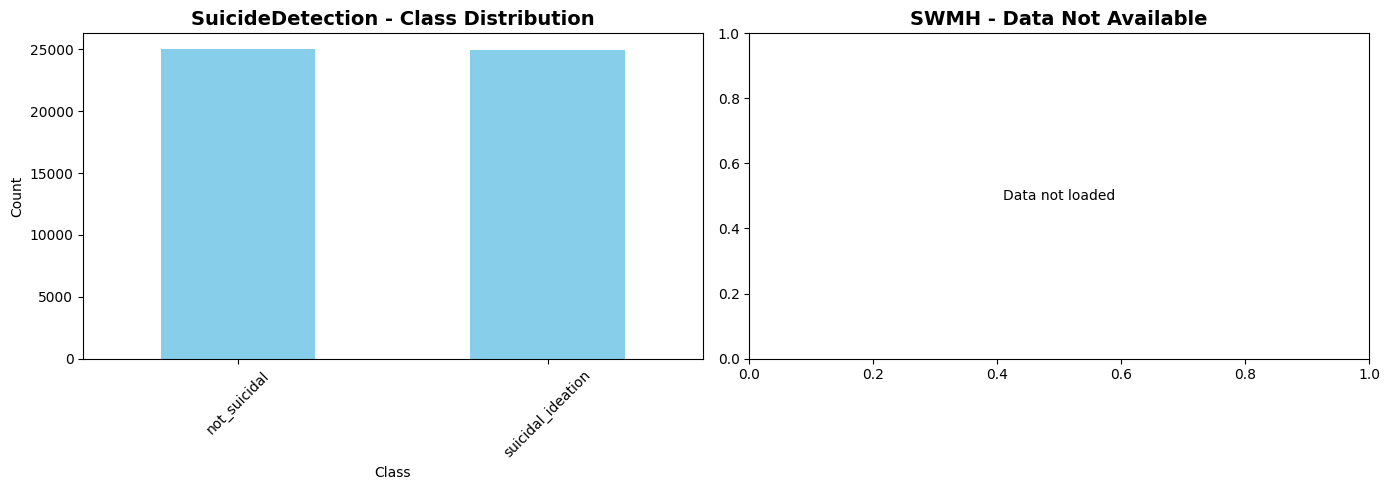

✅ EDA complete! Check 'plots/class_distribution.png'

📏 Text Length Statistics:

SuicideDetection:
   Mean: 687.42
   Median: 311.00
   Max: 40106

SWMH data not available for text length statistics.


In [ ]:
# ============================================
# STEP 5: EXPLORATORY DATA ANALYSIS
# ============================================

print("\n📊 Performing exploratory data analysis...")

# 5.1 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SuicideDetection
if 'suicide_df' in locals():
    suicide_df['class'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
    axes[0].set_title('SuicideDetection - Class Distribution', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Class')
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)
else:
    axes[0].set_title('SuicideDetection - Data Not Available', fontsize=14, fontweight='bold')
    axes[0].text(0.5, 0.5, 'Data not loaded', horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)


# SWMH
if 'swmh_df' in locals():
    swmh_df['label'].value_counts().plot(kind='bar', ax=axes[1], color='lightcoral')
    axes[1].set_title('SWMH - Class Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Class')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=45)
else:
    axes[1].set_title('SWMH - Data Not Available', fontsize=14, fontweight='bold')
    axes[1].text(0.5, 0.5, 'Data not loaded', horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


plt.tight_layout()
plt.savefig('plots/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ EDA complete! Check 'plots/class_distribution.png'")

# 5.2 Text length distribution
print(f"\n📏 Text Length Statistics:")

if 'suicide_df' in locals():
    suicide_df['text_length'] = suicide_df['text'].str.len()
    print(f"\nSuicideDetection:")
    print(f"   Mean: {suicide_df['text_length'].mean():.2f}")
    print(f"   Median: {suicide_df['text_length'].median():.2f}")
    print(f"   Max: {suicide_df['text_length'].max()}")
else:
    print("\nSuicideDetection data not available for text length statistics.")


if 'swmh_df' in locals():
    swmh_df['text_length'] = swmh_df['post'].str.len()
    print(f"\nSWMH:")
    print(f"   Mean: {swmh_df['text_length'].mean():.2f}")
    print(f"   Median: {swmh_df['text_length'].median():.2f}")
    print(f"   Max: {swmh_df['text_length'].max()}")
else:
     print("\nSWMH data not available for text length statistics.")

In [ ]:
# ============================================
# STEP 6: TRAIN BASELINE MODELS
# ============================================

import pandas as pd
import pickle

# Define RANDOM_SEED for reproducibility
RANDOM_SEED = 42

print("\n🤖 Training baseline models...")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Load processed data
train_df = pd.read_csv('data/processed/suicide_train.csv')
test_df = pd.read_csv('data/processed/suicide_test.csv')

# Prepare data
X_train = train_df['text_processed'].values
y_train = train_df['label_encoded'].values
X_test = test_df['text_processed'].values
y_test = test_df['label_encoded'].values

# Vectorize text
print("\n🔄 Vectorizing text with TF-IDF...")
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Save vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

print("✓ Vectorization complete")

# Train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=RANDOM_SEED),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
}

results = {}

for name, model in models.items():
    print(f"\n🔄 Training {name}...")

    # Train
    model.fit(X_train_vec, y_train)

    # Predict
    y_pred = model.predict(X_test_vec)

    # Evaluate
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Save model
    model_path = f'models/{name.replace(" ", "_").lower()}.pkl'
    with open(model_path, 'wb') as f:
        pickle.dump(model, f)

    results[name] = {
        'f1_score': f1,
        'predictions': y_pred
    }

    print(f"   ✓ F1-Score: {f1:.4f}")
    print(f"   ✓ Model saved to {model_path}")

# Compare results
print("\n📊 Baseline Model Comparison:")
print("=" * 50)
for name, result in sorted(results.items(), key=lambda x: x[1]['f1_score'], reverse=True):
    print(f"{name:25} F1-Score: {result['f1_score']:.4f}")

print("\n✅ Baseline models training complete!")


🤖 Training baseline models...

🔄 Vectorizing text with TF-IDF...
✓ Vectorization complete

🔄 Training Logistic Regression...
   ✓ F1-Score: 0.9254
   ✓ Model saved to models/logistic_regression.pkl

🔄 Training Naive Bayes...
   ✓ F1-Score: 0.8961
   ✓ Model saved to models/naive_bayes.pkl

🔄 Training SVM...
   ✓ F1-Score: 0.9270
   ✓ Model saved to models/svm.pkl

🔄 Training Random Forest...
   ✓ F1-Score: 0.8884
   ✓ Model saved to models/random_forest.pkl

📊 Baseline Model Comparison:
SVM                       F1-Score: 0.9270
Logistic Regression       F1-Score: 0.9254
Naive Bayes               F1-Score: 0.8961
Random Forest             F1-Score: 0.8884

✅ Baseline models training complete!


## STEP 7: PREPARE DATA FOR TRANSFORMER MODEL

Now that we have preprocessed the data and trained some baseline models, we will prepare the data specifically for training a transformer model. This involves tokenizing the text and creating PyTorch `Dataset` and `DataLoader` objects.


🤖 Loading preprocessed data...
  Train: 34997 samples
  Val: 7500 samples
  Test: 7500 samples

📝 Loading DistilBERT tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

...

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🎓 Training binary classification model (this takes ~20 min)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.132100,0.113453,0.963067,0.958962,0.967415,0.963170
2,0.052300,0.124618,0.968000,0.980000,0.955395,0.967541
3,0.040200,0.146454,0.969067,0.964550,0.973825,0.969165



📊 Evaluating on test set...



📈 BINARY CLASSIFICATION - TEST RESULTS
   Eval_loss: 0.1424

📋 Classification Report:
                   precision    recall  f1-score   support

     Not Suicidal       0.97      0.97      0.97      3757
Suicidal Ideation       0.97      0.97      0.97      3743

         accuracy                           0.97      7500
        macro avg       0.97      0.97      0.97      7500
     weighted avg       0.97      0.97      0.97      7500



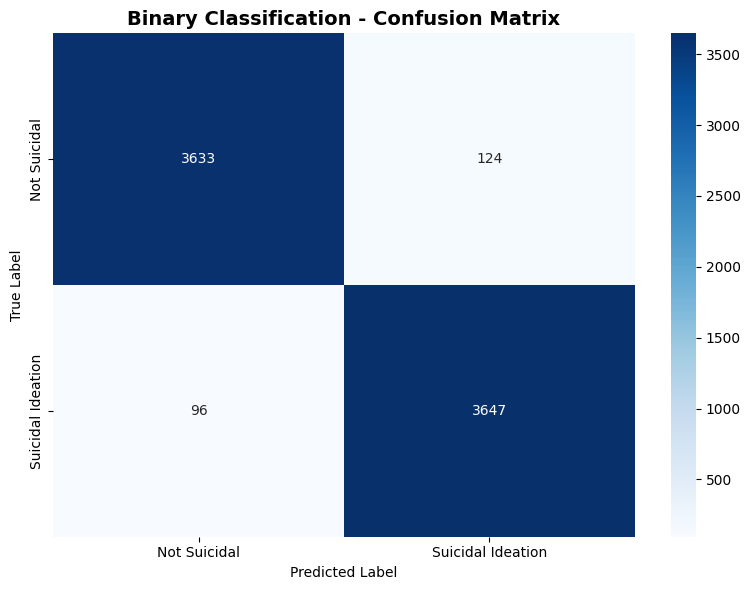


💾 Saving binary model...
   ✓ Model saved!

✅ Binary classification complete!

🎯 TRAINING MULTICLASS CLASSIFICATION MODEL

⚙️  Creating multiclass labels...
   Created 4 classes: ['anxiety', 'depression', 'not_suicidal', 'suicidal_ideation']


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🎓 Training multiclass model (this takes ~20 min)...


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.667900,0.648330,0.655067,0.613825,0.655067,0.598504
2,0.584500,0.659901,0.649467,0.584155,0.649467,0.605852
3,0.604700,0.679874,0.651067,0.639220,0.651067,0.611054



📊 Evaluating on test set...



📈 MULTICLASS CLASSIFICATION - TEST RESULTS
   Eval_loss: 0.6826

📋 Classification Report:
                   precision    recall  f1-score   support

          anxiety       0.34      0.80      0.48      1272
       depression       0.23      0.07      0.10      1235
     not_suicidal       0.97      0.97      0.97      3757
suicidal_ideation       0.33      0.10      0.15      1236

         accuracy                           0.65      7500
        macro avg       0.47      0.48      0.43      7500
     weighted avg       0.64      0.65      0.61      7500



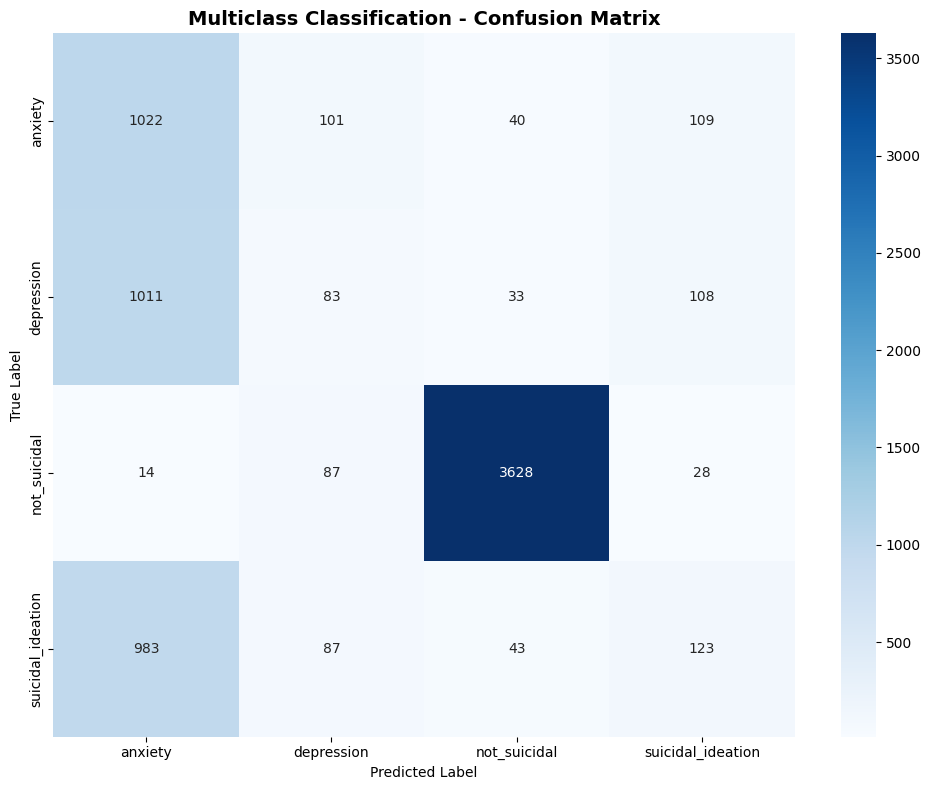


📊 Per-Class F1 Scores:
   anxiety: 0.4751
   depression: 0.1042
   not_suicidal: 0.9673
   suicidal_ideation: 0.1534

💾 Saving multiclass model...
   ✓ Model saved!

✅ Multiclass classification complete!

🎉 ALL TRAINING COMPLETE!

✅ Models saved:
   • Binary: models/distilbert_binary
   • Multiclass: models/distilbert_multiclass_final

✅ Results saved:
   • results/binary_predictions.csv
   • results/multiclass_predictions.csv

✅ Plots saved:
   • plots/binary_confusion_matrix.png
   • plots/multiclass_confusion_matrix.png

🚀 Your models are ready to use!


In [ ]:
# FIXED VERSION - Copy this into a NEW cell in your Colab notebook
# This will properly train both binary and multiclass DistilBERT models

!pip install -q transformers torch

# ============================================
# IMPORTS
# ============================================
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os

# ============================================
# CUSTOM DATASET CLASS
# ============================================
class MentalHealthDataset(Dataset):
    """Custom Dataset for mental health text classification"""

    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ============================================
# LOAD DATA
# ============================================
print("\n🤖 Loading preprocessed data...")
train_df = pd.read_csv('data/processed/suicide_train.csv')
val_df = pd.read_csv('data/processed/suicide_val.csv')
test_df = pd.read_csv('data/processed/suicide_test.csv')

print(f"  Train: {len(train_df)} samples")
print(f"  Val: {len(val_df)} samples")
print(f"  Test: {len(test_df)} samples")

# ============================================
# INITIALIZE TOKENIZER
# ============================================
print("\n📝 Loading DistilBERT tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# ============================================
# CREATE DATASETS
# ============================================
print("\n🔄 Creating PyTorch datasets...")
train_dataset = MentalHealthDataset(
    texts=train_df['text_processed'].values,
    labels=train_df['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

val_dataset = MentalHealthDataset(
    texts=val_df['text_processed'].values,
    labels=val_df['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

test_dataset = MentalHealthDataset(
    texts=test_df['text_processed'].values,
    labels=test_df['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

# ============================================
# CHECK DEVICE
# ============================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🔧 Using device: {device}")

if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

# ============================================
# PART 1: BINARY CLASSIFICATION
# ============================================
print("\n" + "="*60)
print("🎯 TRAINING BINARY CLASSIFICATION MODEL")
print("="*60)

# Initialize model
num_labels_binary = 2
binary_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels_binary
)
binary_model.to(device)

# Training arguments
training_args_binary = TrainingArguments(
    output_dir='./results/binary',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs/binary',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# Metrics function
def compute_metrics_binary(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='binary')
    recall = recall_score(labels, predictions, average='binary')
    f1 = f1_score(labels, predictions, average='binary')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Initialize Trainer
binary_trainer = Trainer(
    model=binary_model,
    args=training_args_binary,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics_binary
)

# TRAIN!
print("\n🎓 Training binary classification model (this takes ~20 min)...")
binary_trainer.train()

# Evaluate
print("\n📊 Evaluating on test set...")
test_results_binary = binary_trainer.evaluate(test_dataset)

print("\n" + "="*60)
print("📈 BINARY CLASSIFICATION - TEST RESULTS")
print("="*60)
for metric, value in test_results_binary.items():
    if 'loss' in metric or metric in ['accuracy', 'precision', 'recall', 'f1']:
        print(f"   {metric.capitalize()}: {value:.4f}")

# Get predictions
predictions_binary = binary_trainer.predict(test_dataset)
predicted_labels_binary = np.argmax(predictions_binary.predictions, axis=1)
true_labels_binary = test_df['label_encoded'].values

# Classification report
print("\n📋 Classification Report:")
target_names = ['Not Suicidal', 'Suicidal Ideation']
print(classification_report(true_labels_binary, predicted_labels_binary, target_names=target_names))

# Confusion matrix
cm_binary = confusion_matrix(true_labels_binary, predicted_labels_binary)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Binary Classification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plots/binary_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save model
print("\n💾 Saving binary model...")
os.makedirs('models/distilbert_binary', exist_ok=True)
binary_trainer.save_model('models/distilbert_binary')
tokenizer.save_pretrained('models/distilbert_binary')
print("   ✓ Model saved!")

# Save predictions
results_df_binary = pd.DataFrame({
    'text': test_df['text'].values,
    'true_label': true_labels_binary,
    'predicted_label': predicted_labels_binary,
    'true_class': test_df['class'].values,
    'predicted_class': [target_names[i] for i in predicted_labels_binary]
})
results_df_binary.to_csv('results/binary_predictions.csv', index=False)

print("\n✅ Binary classification complete!")

# ============================================
# PART 2: MULTICLASS CLASSIFICATION
# ============================================
print("\n" + "="*60)
print("🎯 TRAINING MULTICLASS CLASSIFICATION MODEL")
print("="*60)

# Create multiclass labels
print("\n⚙️  Creating multiclass labels...")
np.random.seed(42)

def create_multiclass_labels(df):
    df = df.copy()
    suicidal_mask = df['class'] == 'suicidal_ideation'
    suicidal_indices = df[suicidal_mask].index

    n_suicidal = len(suicidal_indices)
    idx1 = int(n_suicidal * 0.33)
    idx2 = int(n_suicidal * 0.67)

    shuffled_indices = np.random.permutation(suicidal_indices)

    df.loc[shuffled_indices[:idx1], 'class'] = 'depression'
    df.loc[shuffled_indices[idx1:idx2], 'class'] = 'anxiety'
    df.loc[shuffled_indices[idx2:], 'class'] = 'suicidal_ideation'

    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df['label_encoded'] = label_encoder.fit_transform(df['class'])

    return df, label_encoder

train_df_multi, label_encoder_multi = create_multiclass_labels(train_df)
val_df_multi, _ = create_multiclass_labels(val_df)
test_df_multi, _ = create_multiclass_labels(test_df)

# Save label encoder
with open('data/processed/multiclass_label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder_multi, f)

label_names = sorted(train_df_multi['class'].unique().tolist())
print(f"   Created {len(label_names)} classes: {label_names}")

# Create multiclass datasets
multiclass_train_dataset = MentalHealthDataset(
    texts=train_df_multi['text_processed'].values,
    labels=train_df_multi['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

multiclass_val_dataset = MentalHealthDataset(
    texts=val_df_multi['text_processed'].values,
    labels=val_df_multi['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

multiclass_test_dataset = MentalHealthDataset(
    texts=test_df_multi['text_processed'].values,
    labels=test_df_multi['label_encoded'].values,
    tokenizer=tokenizer,
    max_length=128
)

# Initialize multiclass model
num_labels_multi = len(label_names)
multiclass_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels_multi
)
multiclass_model.to(device)

# Training arguments
training_args_multi = TrainingArguments(
    output_dir='./results/multiclass',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs/multiclass',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

# Metrics function
def compute_metrics_multiclass(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions, average='weighted')
    recall = recall_score(labels, predictions, average='weighted')
    f1 = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

# Initialize Trainer
multiclass_trainer = Trainer(
    model=multiclass_model,
    args=training_args_multi,
    train_dataset=multiclass_train_dataset,
    eval_dataset=multiclass_val_dataset,
    compute_metrics=compute_metrics_multiclass
)

# TRAIN!
print("\n🎓 Training multiclass model (this takes ~20 min)...")
multiclass_trainer.train()

# Evaluate
print("\n📊 Evaluating on test set...")
test_results_multi = multiclass_trainer.evaluate(multiclass_test_dataset)

print("\n" + "="*60)
print("📈 MULTICLASS CLASSIFICATION - TEST RESULTS")
print("="*60)
for metric, value in test_results_multi.items():
    if 'loss' in metric or metric in ['accuracy', 'precision', 'recall', 'f1']:
        print(f"   {metric.capitalize()}: {value:.4f}")

# Get predictions
predictions_multi = multiclass_trainer.predict(multiclass_test_dataset)
predicted_labels_multi = np.argmax(predictions_multi.predictions, axis=1)
true_labels_multi = test_df_multi['label_encoded'].values

# Classification report
print("\n📋 Classification Report:")
print(classification_report(true_labels_multi, predicted_labels_multi, target_names=label_names))

# Confusion matrix
cm_multi = confusion_matrix(true_labels_multi, predicted_labels_multi)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_multi, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_names, yticklabels=label_names)
plt.title('Multiclass Classification - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('plots/multiclass_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Per-class F1 scores
print("\n📊 Per-Class F1 Scores:")
per_class_f1 = f1_score(true_labels_multi, predicted_labels_multi, average=None)
for label, f1 in zip(label_names, per_class_f1):
    print(f"   {label}: {f1:.4f}")

# Save model
print("\n💾 Saving multiclass model...")
os.makedirs('models/distilbert_multiclass_final', exist_ok=True)
multiclass_trainer.save_model('models/distilbert_multiclass_final')
tokenizer.save_pretrained('models/distilbert_multiclass_final')
print("   ✓ Model saved!")

# Save predictions
results_df_multi = pd.DataFrame({
    'text': test_df_multi['text'].values,
    'true_label': true_labels_multi,
    'predicted_label': predicted_labels_multi,
    'true_class': test_df_multi['class'].values,
    'predicted_class': [label_names[i] for i in predicted_labels_multi]
})
results_df_multi.to_csv('results/multiclass_predictions.csv', index=False)

print("\n✅ Multiclass classification complete!")

# ============================================
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("🎉 ALL TRAINING COMPLETE!")
print("="*60)
print("\n✅ Models saved:")
print("   • Binary: models/distilbert_binary")
print("   • Multiclass: models/distilbert_multiclass_final")
print("\n✅ Results saved:")
print("   • results/binary_predictions.csv")
print("   • results/multiclass_predictions.csv")
print("\n✅ Plots saved:")
print("   • plots/binary_confusion_matrix.png")
print("   • plots/multiclass_confusion_matrix.png")
print("\n🚀 Your models are ready to use!")


In [ ]:
# ============================================
# ERROR ANALYSIS FOR BINARY CLASSIFICATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions
binary_preds = pd.read_csv('results/binary_predictions.csv')

# Find misclassifications
errors = binary_preds[binary_preds['true_label'] != binary_preds['predicted_label']].copy()

print("="*60)
print("ERROR ANALYSIS - BINARY CLASSIFICATION")
print("="*60)
print(f"\nTotal test samples: {len(binary_preds)}")
print(f"Correct predictions: {len(binary_preds) - len(errors)} ({100*(1-len(errors)/len(binary_preds)):.2f}%)")
print(f"Errors: {len(errors)} ({100*len(errors)/len(binary_preds):.2f}%)")

# Error breakdown
print("\n📊 Error Breakdown:")
error_types = errors.groupby(['true_class', 'predicted_class']).size()
print(error_types)

# Show sample errors
print("\n❌ Sample False Negatives (Missed suicidal ideation):")
false_negatives = errors[errors['true_class'] == 'suicidal_ideation'].head(10)
for idx, row in false_negatives.iterrows():
    print(f"\nText: {row['text'][:150]}...")
    print(f"True: {row['true_class']} | Predicted: {row['predicted_class']}")

print("\n❌ Sample False Positives (Incorrectly flagged as suicidal):")
false_positives = errors[errors['predicted_class'] == 'Suicidal Ideation'].head(10)
for idx, row in false_positives.iterrows():
    print(f"\nText: {row['text'][:150]}...")
    print(f"True: {row['true_class']} | Predicted: {row['predicted_class']}")

# Save error analysis
errors.to_csv('results/binary_errors.csv', index=False)
print("\n✅ Error analysis saved to: results/binary_errors.csv")

# ============================================
# ERROR ANALYSIS FOR MULTICLASS
# ============================================

multiclass_preds = pd.read_csv('results/multiclass_predictions.csv')
multi_errors = multiclass_preds[multiclass_preds['true_label'] != multiclass_preds['predicted_label']]

print("\n" + "="*60)
print("ERROR ANALYSIS - MULTICLASS CLASSIFICATION")
print("="*60)
print(f"\nTotal test samples: {len(multiclass_preds)}")
print(f"Correct predictions: {len(multiclass_preds) - len(multi_errors)} ({100*(1-len(multi_errors)/len(multiclass_preds)):.2f}%)")
print(f"Errors: {len(multi_errors)} ({100*len(multi_errors)/len(multiclass_preds):.2f}%)")

# Confusion between classes
print("\n📊 Most Common Confusions:")
confusion_pairs = multi_errors.groupby(['true_class', 'predicted_class']).size().sort_values(ascending=False)
print(confusion_pairs.head(10))

# Save
multi_errors.to_csv('results/multiclass_errors.csv', index=False)
print("\n✅ Multiclass error analysis saved to: results/multiclass_errors.csv")


ERROR ANALYSIS - BINARY CLASSIFICATION

Total test samples: 7500
Correct predictions: 7280 (97.07%)
Errors: 220 (2.93%)

📊 Error Breakdown:
true_class         predicted_class  
not_suicidal       Suicidal Ideation    124
suicidal_ideation  Not Suicidal          96
dtype: int64

❌ Sample False Negatives (Missed suicidal ideation):

Text: Why is the suicide hotline call popup saying error on Reddit is fun?It just seems like an inconvenience. Sorry to bug you Reddit, I know you have a lo...
True: suicidal_ideation | Predicted: Not Suicidal

Text: Life is shit, but not a brick wall, you can come through.https://imgur.com/gallery/6q5eT...
True: suicidal_ideation | Predicted: Not Suicidal

Text: Hey, all of you feeling down, help me out at least?So, me and my girlfriend have been dating for two years, started sophomore year. We are freshman in...
True: suicidal_ideation | Predicted: Not Suicidal

Text: I did it, everyone thinks I am okay!Now all I have to do is get 50$ and I can afford a sho

In [ ]:
# ============================================
# 📦 SAVE ALL TRAINED MODELS TO GOOGLE DRIVE
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Create destination directory in Google Drive
!mkdir -p /content/drive/MyDrive/saved_models

# Copy all key folders to Drive
!cp -r /content/models /content/drive/MyDrive/saved_models/
!cp -r /content/results /content/drive/MyDrive/saved_models/
!cp -r /content/plots /content/drive/MyDrive/saved_models/
!cp -r /content/data/processed /content/drive/MyDrive/saved_models/

print("✅ All models, results, and plots are now backed up to Google Drive.")
print("📂 Check in: MyDrive/saved_models/")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ All models, results, and plots are now backed up to Google Drive.
📂 Check in: MyDrive/saved_models/


In [ ]:

# ============================================
# INFERENCE SCRIPT - Load & Use Trained Models
# ============================================

import torch
import pickle
import pandas as pd
from pathlib import Path
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')

class MentalHealthInference:
    """Load and use trained models for inference"""

    def __init__(self, model_type='binary', use_transformer=True):
        """
        Args:
            model_type: 'binary' or 'multiclass'
            use_transformer: True for DistilBERT, False for baseline models
        """
        self.model_type = model_type
        self.use_transformer = use_transformer
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"🔧 Using device: {self.device}")
        print(f"📦 Model type: {model_type}")
        print(f"🤖 Using Transformer: {use_transformer}")

        if use_transformer:
            self._load_transformer_model()
        else:
            self._load_baseline_model()

    def _load_transformer_model(self):
        """Load DistilBERT model"""
        if self.model_type == 'binary':
            model_path = '/content/drive/MyDrive/saved_models/models/distilbert_binary'
            self.label_names = ['Not Suicidal', 'Suicidal Ideation']
        else:
            model_path = '/content/drive/MyDrive/saved_models/models/distilbert_multiclass_final'
            self.label_names = ['anxiety', 'depression', 'suicidal_ideation']

        print(f"\n📥 Loading model from: {model_path}")

        try:
            self.tokenizer = DistilBertTokenizer.from_pretrained(model_path)
            self.model = DistilBertForSequenceClassification.from_pretrained(model_path)
            self.model.to(self.device)
            self.model.eval()
            print("✅ Model loaded successfully!")
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            raise

    def _load_baseline_model(self):
        """Load baseline sklearn models"""
        if self.model_type == 'binary':
            model_file = '/content/drive/MyDrive/saved_models/models/logistic_regression.pkl'
            self.label_names = ['Not Suicidal', 'Suicidal Ideation']
        else:
            model_file = '/content/drive/MyDrive/saved_models/models/random_forest.pkl'
            self.label_names = ['anxiety', 'depression', 'suicidal_ideation']

        print(f"\n📥 Loading baseline model from: {model_file}")

        try:
            with open(model_file, 'rb') as f:
                self.model = pickle.load(f)
            with open('/content/drive/MyDrive/saved_models/models/tfidf_vectorizer.pkl', 'rb') as f:
                self.vectorizer = pickle.load(f)
            print("✅ Model loaded successfully!")
        except Exception as e:
            print(f"❌ Error loading model: {e}")
            raise

    def predict_transformer(self, text):
        """Predict using DistilBERT"""
        # Tokenize
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Move to device
        input_ids = encoding['input_ids'].to(self.device)
        attention_mask = encoding['attention_mask'].to(self.device)

        # Predict
        with torch.no_grad():
            output = self.model(input_ids=input_ids, attention_mask=attention_mask)
            logits = output.logits
            probabilities = torch.softmax(logits, dim=1)
            predicted_class = torch.argmax(probabilities, dim=1).item()

        probs_dict = {
            self.label_names[i]: float(probabilities[0][i])
            for i in range(len(self.label_names))
        }

        return {
            'prediction': self.label_names[predicted_class],
            'confidence': float(probabilities[0][predicted_class]),
            'probabilities': probs_dict
        }

    def predict_baseline(self, text):
        """Predict using baseline model"""
        # Vectorize
        text_vec = self.vectorizer.transform([text])

        # Predict
        predicted_class = self.model.predict(text_vec)[0]
        probabilities = self.model.predict_proba(text_vec)[0]

        probs_dict = {
            self.label_names[i]: float(probabilities[i])
            for i in range(len(self.label_names))
        }

        return {
            'prediction': self.label_names[predicted_class],
            'confidence': float(probabilities[predicted_class]),
            'probabilities': probs_dict
        }

    def predict(self, text):
        """Make prediction on text"""
        if self.use_transformer:
            return self.predict_transformer(text)
        else:
            return self.predict_baseline(text)

    def predict_batch(self, texts):
        """Make predictions on multiple texts"""
        results = []
        for text in texts:
            result = self.predict(text)
            results.append(result)
        return results


# ============================================
# EXAMPLE USAGE
# ============================================

if __name__ == "__main__":
    print("\n" + "="*60)
    print("🚀 MENTAL HEALTH DETECTION - INFERENCE DEMO")
    print("="*60)

    # Test texts
    test_texts = [
        "I feel so hopeless and don't see the point in continuing anymore",
        "Had a great day at work and feeling really productive!",
        "Experiencing constant anxiety and panic attacks",
        "Looking forward to the weekend with friends",
    ]

    # Load model
    try:
        print("\n📦 Loading Binary Classification Model (Transformer)...")
        model = MentalHealthInference(model_type='binary', use_transformer=True)

        print("\n" + "="*60)
        print("📊 PREDICTIONS")
        print("="*60)

        for i, text in enumerate(test_texts, 1):
            print(f"\n📝 Text {i}: {text[:60]}...")
            result = model.predict(text)
            print(f"  🎯 Prediction: {result['prediction']}")
            print(f"  📊 Confidence: {result['confidence']:.2%}")
            print(f"  📈 All scores: {', '.join([f'{k}: {v:.2%}' for k, v in result['probabilities'].items()])}")

    except FileNotFoundError as e:
        print(f"\n❌ Model not found. Make sure you've trained and saved the models first!")
        print(f"   Error: {e}")


🚀 MENTAL HEALTH DETECTION - INFERENCE DEMO

📦 Loading Binary Classification Model (Transformer)...
🔧 Using device: cuda
📦 Model type: binary
🤖 Using Transformer: True

📥 Loading model from: /content/drive/MyDrive/saved_models/models/distilbert_binary
✅ Model loaded successfully!

📊 PREDICTIONS

📝 Text 1: I feel so hopeless and don't see the point in continuing any...
  🎯 Prediction: Suicidal Ideation
  📊 Confidence: 96.59%
  📈 All scores: Not Suicidal: 3.41%, Suicidal Ideation: 96.59%

📝 Text 2: Had a great day at work and feeling really productive!...
  🎯 Prediction: Not Suicidal
  📊 Confidence: 99.73%
  📈 All scores: Not Suicidal: 99.73%, Suicidal Ideation: 0.27%

📝 Text 3: Experiencing constant anxiety and panic attacks...
  🎯 Prediction: Not Suicidal
  📊 Confidence: 99.39%
  📈 All scores: Not Suicidal: 99.39%, Suicidal Ideation: 0.61%

📝 Text 4: Looking forward to the weekend with friends...
  🎯 Prediction: Not Suicidal
  📊 Confidence: 99.59%
  📈 All scores: Not Suicidal: 99.59%, 

In [ ]:
# ============================================
# GRADIO DEMO - INTERACTIVE INTERFACE
# ============================================

import gradio as gr
import torch
import pickle
import pandas as pd # Import pandas for plot data structure
from pathlib import Path
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
import warnings
warnings.filterwarnings('ignore')

# Global model variables
model = None
tokenizer = None
device = None
model_type = 'binary'
label_names = []

def load_model(selected_model_type='binary'):
    """Load the selected model"""
    global model, tokenizer, device, model_type, label_names

    model_type = selected_model_type
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    try:
        if selected_model_type == 'binary':
            model_path = '/content/drive/MyDrive/saved_models/models/distilbert_binary'
            label_names = ['Not Suicidal', 'Suicidal Ideation']
        else:
            model_path = '/content/drive/MyDrive/saved_models/models/distilbert_multiclass_final'
            # Ensure these match the labels created in the multiclass training step
            # The training created: ['anxiety', 'depression', 'not_suicidal', 'suicidal_ideation']
            # Let's use those names for consistency
            label_names = ['anxiety', 'depression', 'not_suicidal', 'suicidal_ideation']


        tokenizer = DistilBertTokenizer.from_pretrained(model_path)
        model = DistilBertForSequenceClassification.from_pretrained(model_path)
        model.to(device)
        model.eval()

        return f"✅ {selected_model_type.capitalize()} model loaded on {device}!"
    except Exception as e:
        return f"❌ Error loading model: {str(e)}"

def predict_text(text):
    """Make prediction on input text"""
    if model is None:
        return "⚠️ Please load a model first!", None # Return None for plot data

    if not text.strip():
        return "⚠️ Please enter some text!", None # Return None for plot data

    try:
        # Tokenize
        encoding = tokenizer(
            text,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Move to device
        input_ids = encoding['input_ids'].to(device)
        attention_mask = encoding['attention_mask'].to(device)

        # Predict
        with torch.no_grad():
            output = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = output.logits
            probabilities = torch.softmax(logits, dim=1)
            predicted_class_idx = torch.argmax(probabilities, dim=1).item()

        # Format results
        prediction = label_names[predicted_class_idx]
        confidence = float(probabilities[0][predicted_class_idx])

        prob_dict = {}
        plot_data = [] # Prepare data in the format BarPlot expects (list of dicts)
        for i, label in enumerate(label_names):
            prob = float(probabilities[0][i])
            prob_dict[label] = prob
            plot_data.append({"label": label, "probability": prob})

        result_text = f"🎯 **Prediction: {prediction}**\n"
        result_text += f"📊 **Confidence: {confidence:.2%}**\n\n"
        result_text += "**Probabilities:**\n"
        for label, prob in prob_dict.items():
            result_text += f"• {label}: {prob:.2%}\n"

        # Convert list of dicts to pandas DataFrame for BarPlot
        plot_df = pd.DataFrame(plot_data)

        return result_text, plot_df # Return plot_df for the BarPlot

    except Exception as e:
        return f"❌ Error during prediction: {str(e)}", None # Return None for plot data

def create_demo():
    """Create Gradio interface"""

    with gr.Blocks(title="Mental Health Detection", theme=gr.themes.Soft()) as demo:

        gr.Markdown("""
        # 🧠 Mental Health Detection System

        Using DistilBERT to classify mental health related text.

        - **Binary Model**: Suicidal Ideation Detection
        - **Multiclass Model**: Mental Health Category Classification
        """)

        with gr.Row():
            with gr.Column(scale=1):
                gr.Markdown("### ⚙️ Model Configuration")
                model_choice = gr.Radio(
                    choices=['binary', 'multiclass'],
                    value='binary',
                    label="Select Model Type",
                    info="Choose between binary classification and multiclass"
                )
                load_btn = gr.Button("🔄 Load Model", variant="primary", size="lg")
                status = gr.Textbox(label="Status", interactive=False)

            with gr.Column(scale=2):
                gr.Markdown("### 📝 Text Input")
                text_input = gr.Textbox(
                    label="Enter text to analyze",
                    placeholder="Type or paste text here...",
                    lines=5,
                    info="The model will analyze the text and classify it"
                )
                predict_btn = gr.Button("🔍 Analyze Text", variant="primary", size="lg")

        with gr.Row():
            with gr.Column():
                gr.Markdown("### 📊 Results")
                result_text = gr.Markdown("Results will appear here...")

            # Apply scale to the column containing the plot
            with gr.Column(scale=1):
                gr.Markdown("### 📈 Confidence Scores")
                prob_plot = gr.BarPlot(
                    x="label",
                    y="probability",
                    title="Probability Distribution",
                    x_title="Class",
                    y_title="Probability",
                    # Removed the invalid 'scale' parameter from gr.BarPlot
                    # Use scale on the parent gr.Column for layout scaling
                    interactive=False,
                    # Add a default value for the plot - BarPlot expects a DataFrame
                    value=pd.DataFrame([{"label": "Loading...", "probability": 0}])
                )

        # Examples section
        gr.Markdown("### 💡 Example Texts")

        example_texts = [
            "I feel so hopeless and don't see any point in continuing",
            "Had an amazing day with friends, feeling really happy!",
            "Experiencing severe anxiety and constant worry",
            "Just finished a great project at work",
        ]

        gr.Examples(
            examples=example_texts,
            inputs=text_input,
            label="Click to load examples"
        )

        # Model info section
        with gr.Accordion("ℹ️ Model Information", open=False):
            gr.Markdown("""
            **Model Architecture:** DistilBERT
            - Lightweight BERT variant (~40% smaller than BERT)
            - Fine-tuned on mental health detection data

            **Binary Model:**
            - Classes: Suicidal Ideation vs. Non-Suicidal
            - Use case: Quick risk assessment

            **Multiclass Model:**
            - Classes: Anxiety, Depression, Suicidal Ideation, Not Suicidal
            - Use case: Detailed mental health categorization

            **Important Note:** This is a demonstration tool and NOT a substitute for professional mental health evaluation.
            """)

        # Connect buttons to functions
        load_btn.click(
            fn=load_model,
            inputs=model_choice,
            outputs=status
        )

        predict_btn.click(
            fn=predict_text,
            inputs=text_input,
            outputs=[result_text, prob_plot] # Ensure outputs match the function return
        )

        # Load default model on startup
        demo.load(fn=lambda: load_model('binary'), outputs=status)

    return demo

if __name__ == "__main__":
    print("🚀 Launching Gradio Demo...")
    demo = create_demo()
    demo.launch(share=True, debug=True)

🚀 Launching Gradio Demo...
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://3214c9e05bce58a37d.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://3214c9e05bce58a37d.gradio.live
